In [3]:
import pandas as pd
import numpy as np


In [4]:
class Linear_Regression():
    #Constructor
    def __init__(self,learning_rate,no_of_iteration):
        self.learning_rate=learning_rate
        self.no_of_iteration=no_of_iteration

    def fit(self,X,Y):
        self.m,self.n=X.shape
        #m=no of rows or examples and n=feateures used to  predict the value
        self.w=np.zeros(self.n)
        self.b=0
        self.X=X
        self.Y=Y

        #iterate
        for i in range(0,self.no_of_iteration):
            self.update_weight()


    def update_weight(self):
        Y_prediction=self.predict(self.X)

        dw=-(2*(self.X.T).dot(self.Y-Y_prediction))/self.m
        db=-2*np.sum(self.Y-Y_prediction)/self.m

        #updating the weight

        self.w=self.w-self.learning_rate*dw
        self.b=self.b-self.learning_rate*db




    def predict(self,X):
        return X.dot(self.w)+self.b


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
dataset=pd.read_csv("/home/loki/Developer/Ml/LinearRegression/salary.csv")

In [7]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [8]:
dataset.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [9]:
dataset.shape

(30, 2)

In [10]:
dataset.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [11]:
X=dataset.iloc[:,:-1]
Y=dataset.iloc[:,1]

In [12]:

X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [13]:
Y

0      39343
1      46205
2      37731
3      43525
4      39891
5      56642
6      60150
7      54445
8      64445
9      57189
10     63218
11     55794
12     56957
13     57081
14     61111
15     67938
16     66029
17     83088
18     81363
19     93940
20     91738
21     98273
22    101302
23    113812
24    109431
25    105582
26    116969
27    112635
28    122391
29    121872
Name: Salary, dtype: int64

In [14]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=2)

In [40]:
#LinearRegression
model=Linear_Regression(learning_rate=0.01,no_of_iteration=1000)


In [41]:
model.fit(X_train.values,Y_train.values)

In [42]:
print(model.w[0])

9580.301196603597


In [43]:
test_predicted=model.predict(X_test)
test_predicted

1      35680.781022
0      33764.720782
14     66337.744851
9      58673.503893
21     91246.527962
19     80708.196646
23    101784.859278
6      51967.293056
3      42386.991859
20     88372.437603
dtype: float64

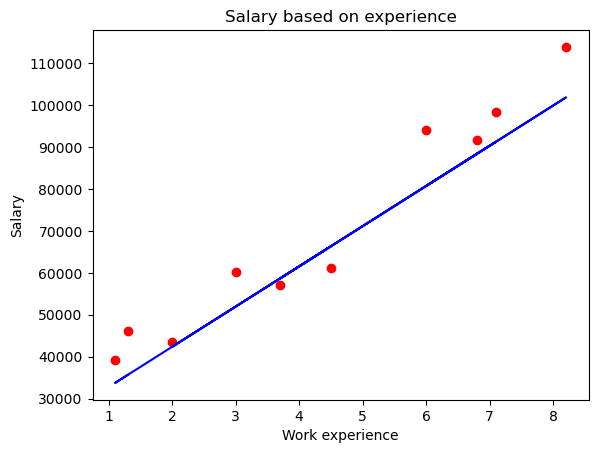

In [44]:
plt.scatter(X_test,Y_test,color='red')
plt.plot(X_test,test_predicted,color='blue')
plt.xlabel("Work experience")
plt.ylabel("Salary")
plt.title("Salary based on experience")
plt.show()